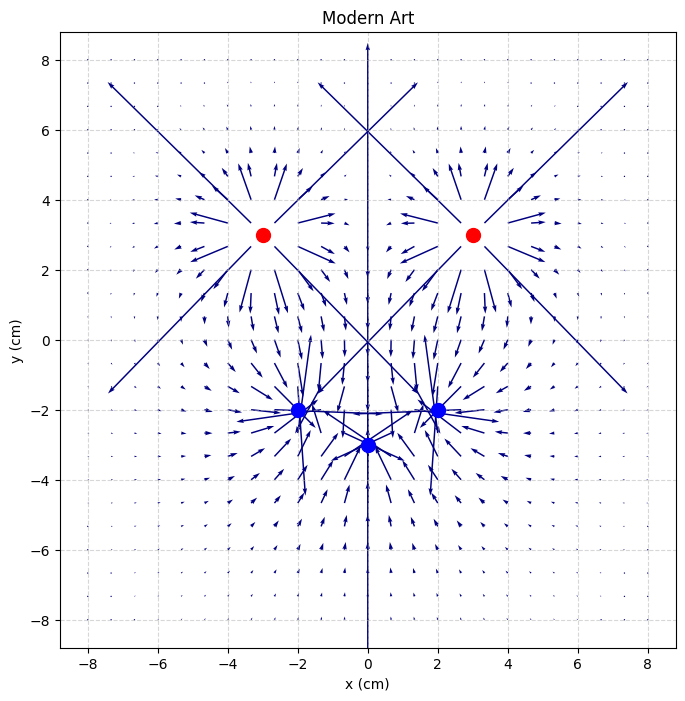

In [2]:
import numpy as np
import matplotlib.pyplot as plt

k = 8.99e9
N = 25

x = np.linspace(-8.0, 8.0, N)
y = np.linspace(-8.0, 8.0, N)
X, Y = np.meshgrid(x, y)

charges = [
    (-3, 3, 1e-6),    
    (3, 3, 1e-6),     
    (-2, -2, -1e-6),  
    (0, -3, -1e-6),  
    (2, -2, -1e-6)    
]

Ex = np.zeros(X.shape)
Ey = np.zeros(Y.shape)

for xq, yq, q in charges:
    dx = X - xq
    dy = Y - yq
    r2 = dx**2 + dy**2
    
    
    r2[r2 == 0] = np.nan
    
    magE = k * q / r2
    thE = np.arctan2(dy, dx)
    
    Ex += magE * np.cos(thE)
    Ey += magE * np.sin(thE)

total_mag = np.sqrt(Ex**2 + Ey**2)
mask = total_mag < 1e6

fig, ax = plt.subplots(figsize=(8, 8))
ax.quiver(X[mask], Y[mask], Ex[mask], Ey[mask], color='navy')

for xq, yq, q in charges:
    color = 'red' if q > 0 else 'blue'
    ax.plot(xq, yq, 'o', color=color, markersize=10)
    
ax.set_aspect('equal')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_title('Modern Art')
ax.grid(True, linestyle='--', alpha=0.5)

plt.savefig("step3_multi_charge.png", dpi=300, bbox_inches='tight')

# Display plot
plt.show()